TODOs:
bei Winkeltripel Darstellung ragen einige Punkte über den Rahmen hinaus
bei Winkeltripel werden Datenpunkte etwas überlappend dargestellt (lieber Quadrat oder Kreis?)

In [1]:

import xarray as xr
import numpy as np
import pickle
from sklearn.preprocessing import MinMaxScaler
from tslearn.utils import to_time_series_dataset
from matplotlib import pyplot as plt
from src import preprocessing
from src import snow_model
from src import land_mask
from src import clustering


/Users/ericwostenberg/Documents/GitHub/snow_storage_and_snowmelt_in_nuclear_winter/.venv/lib/python3.11/site-packages/tslearn/bases/bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


Design Template aus ALLFED Style

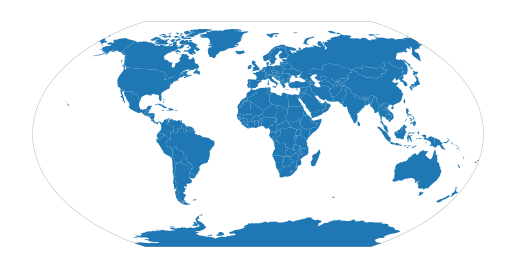

+proj=wintri +type=crs


In [2]:
import geopandas as gpd
# Add border to map, remove gridlines and ticks (after activating ALLFED style)
def plot_winkel_tripel_map(ax): 
    border_geojson = gpd.read_file('https://raw.githubusercontent.com/ALLFED/ALLFED-map-border/main/border.geojson')
    border_geojson.plot(ax=ax, edgecolor='black', linewidth=0.1, facecolor='none')
    ax.set_axis_off()

world = gpd.read_file('/Users/ericwostenberg/Documents/GitHub/snow_storage_and_snowmelt_in_nuclear_winter/data/test_abbildung/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp') # Example world dataset
world = world.to_crs('+proj=wintri') # Change projection to Winkel Tripel

ax = world.plot() # Plot the map
plot_winkel_tripel_map(ax) # Modify style and add border
plt.show()

print(world.crs)

In [2]:
ds = xr.open_dataset("./results/snow_dataset.nc")



In [4]:
data = ds["snow_storage"].max(dim="time")
data = data /10

Mit Cartopy und Robinson Projektion (Rasterdaten)

Schneespeicher

In [16]:
plt.style.use("https://raw.githubusercontent.com/allfed/ALLFED-matplotlib-style-sheet/main/ALLFED.mplstyle")
#Allfed Style entfernt Umrwandung -> muss wieder hinzugefügt werden mit rcParams.update()

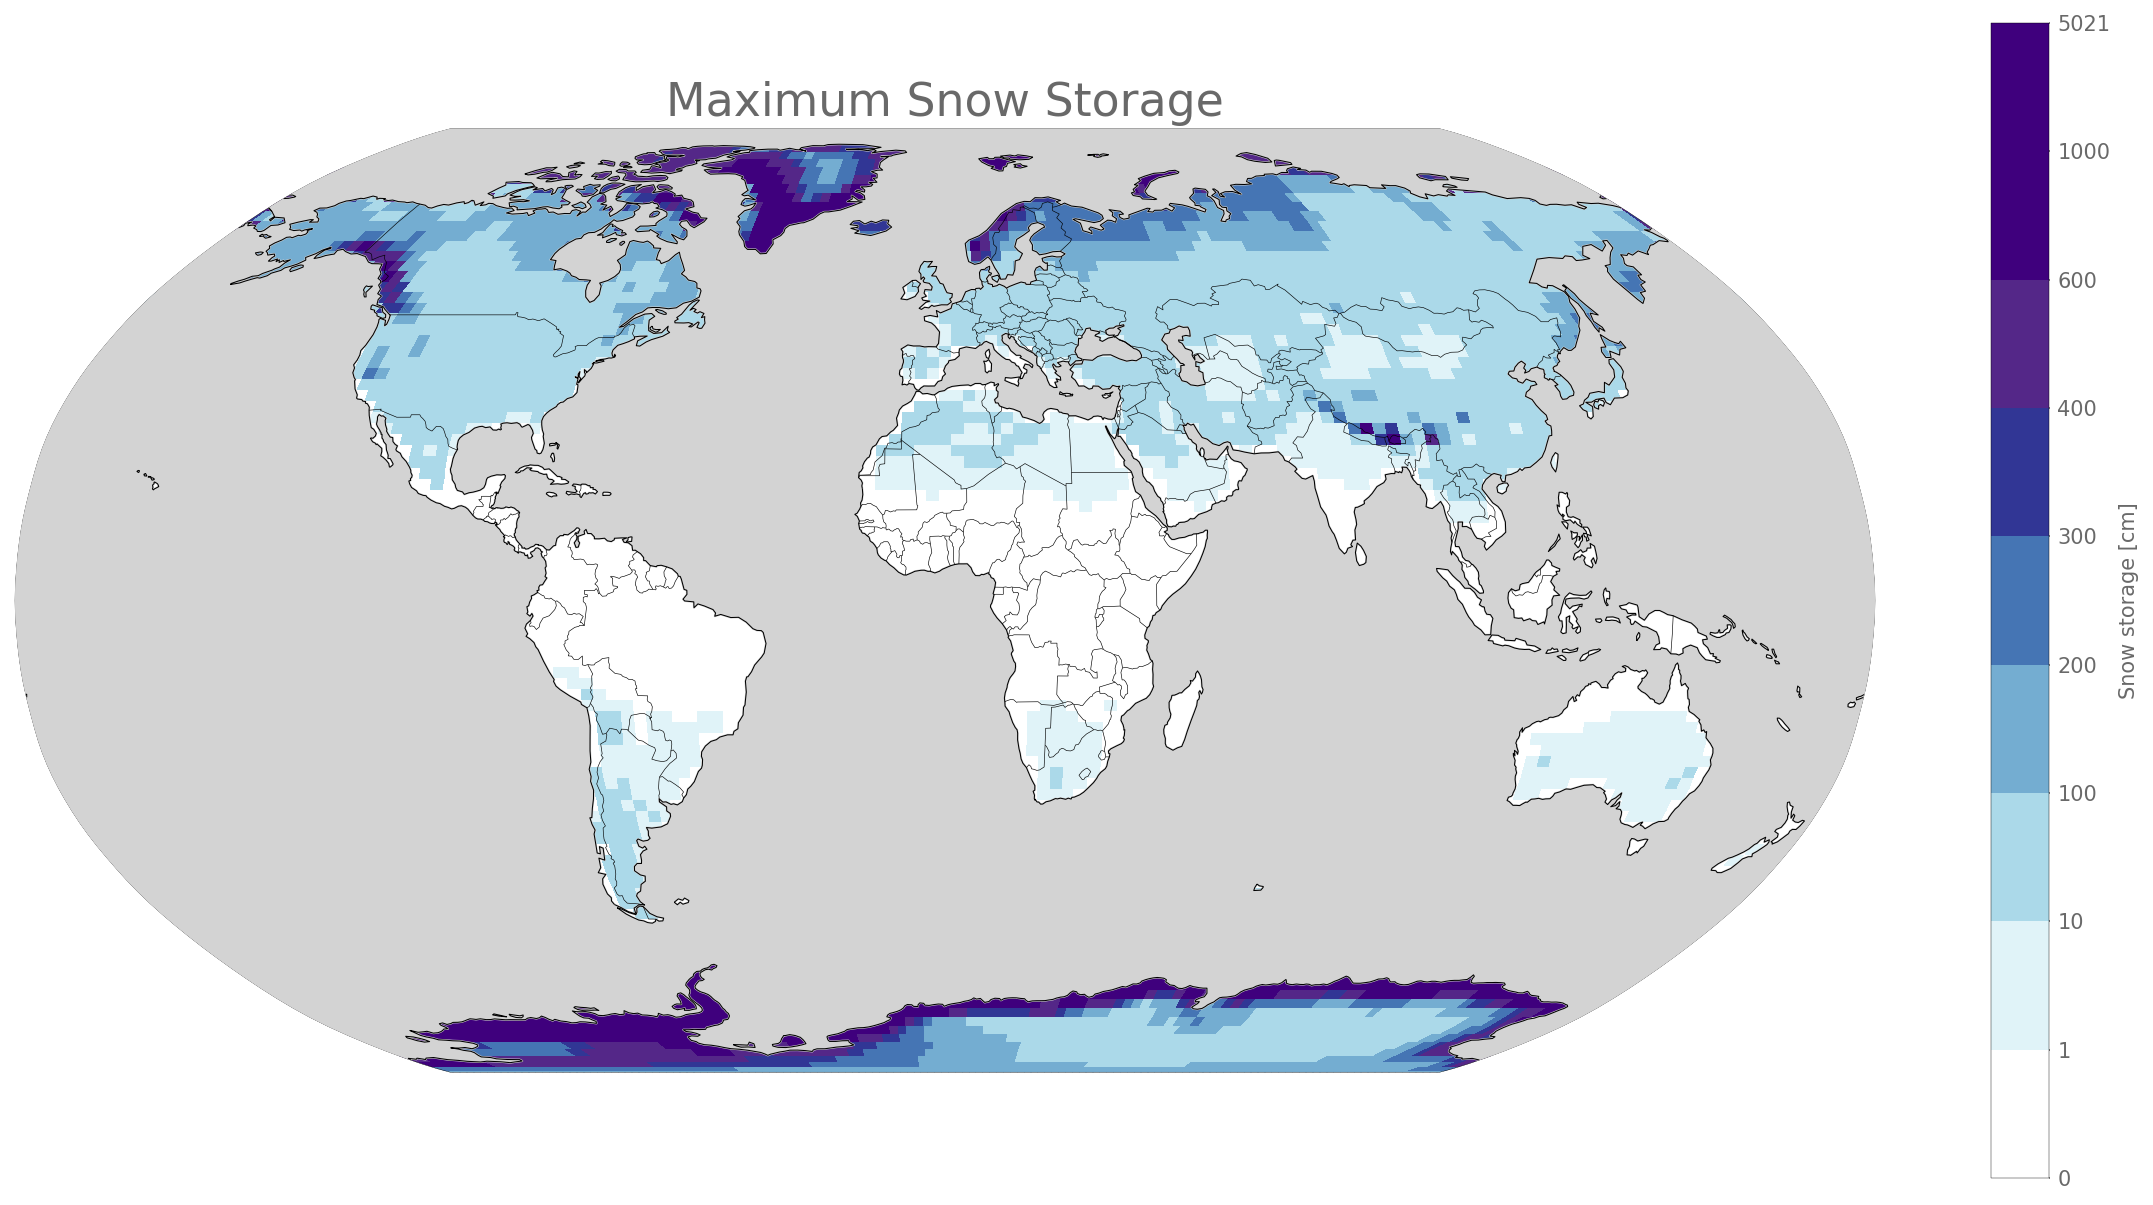

In [36]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

plt.rcParams.update({
    "axes.edgecolor": "black",   # Farbe des Randes
    "axes.linewidth": 0.2,       # Breite des Randes
})

bin_edges = np.array([0, 1, 10, 100, 200, 300, 400, 600, 1000, data.max()])

# Anzahl Klassen
n_classes = len(bin_edges) - 1

# Diskrete Colormap erzeugen
#cmap = plt.get_cmap("YlGnBu", n_classes)
colors = [
        "#ffffff",  # 0–10
        "#e0f3f8",  # 10–100
        "#abd9e9",  # 100–200
        "#74add1",  # 200–300
        "#4575b4",  # 300–400
        "#313695",  # 400–600
        "#542788",  # 600–1000
        "#3f007d",  # >1000
    ]


cmap = mcolors.ListedColormap(colors)

# Norm für Klassengrenzen
norm = mcolors.BoundaryNorm(bin_edges, ncolors=n_classes)

fig = plt.figure(figsize=(20, 10))
ax = plt.axes(projection=ccrs.Robinson())
ax.add_feature(cfeature.OCEAN, color='white')

im = data.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    add_colorbar=True,
    cbar_kwargs={
        "label": "Snow storage [cm]",
        "ticks": bin_edges  # letzte (inf) nicht anzeigen
    }
)

ax.coastlines(linewidth=0.5, zorder=11)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, zorder= 11)
ax.add_feature(cfeature.OCEAN, color='lightgrey', zorder=10)
ax.set_title("Maximum Snow Storage", fontsize=22)


plt.show()

#Darstellung verbessern evtl. grün als Farbe, wo nie Schnee liegt

Schneeschmelze

In [178]:
data = ds["snow_melt"].max(dim="time")
data = data / 10  # Umrechnung in cm 

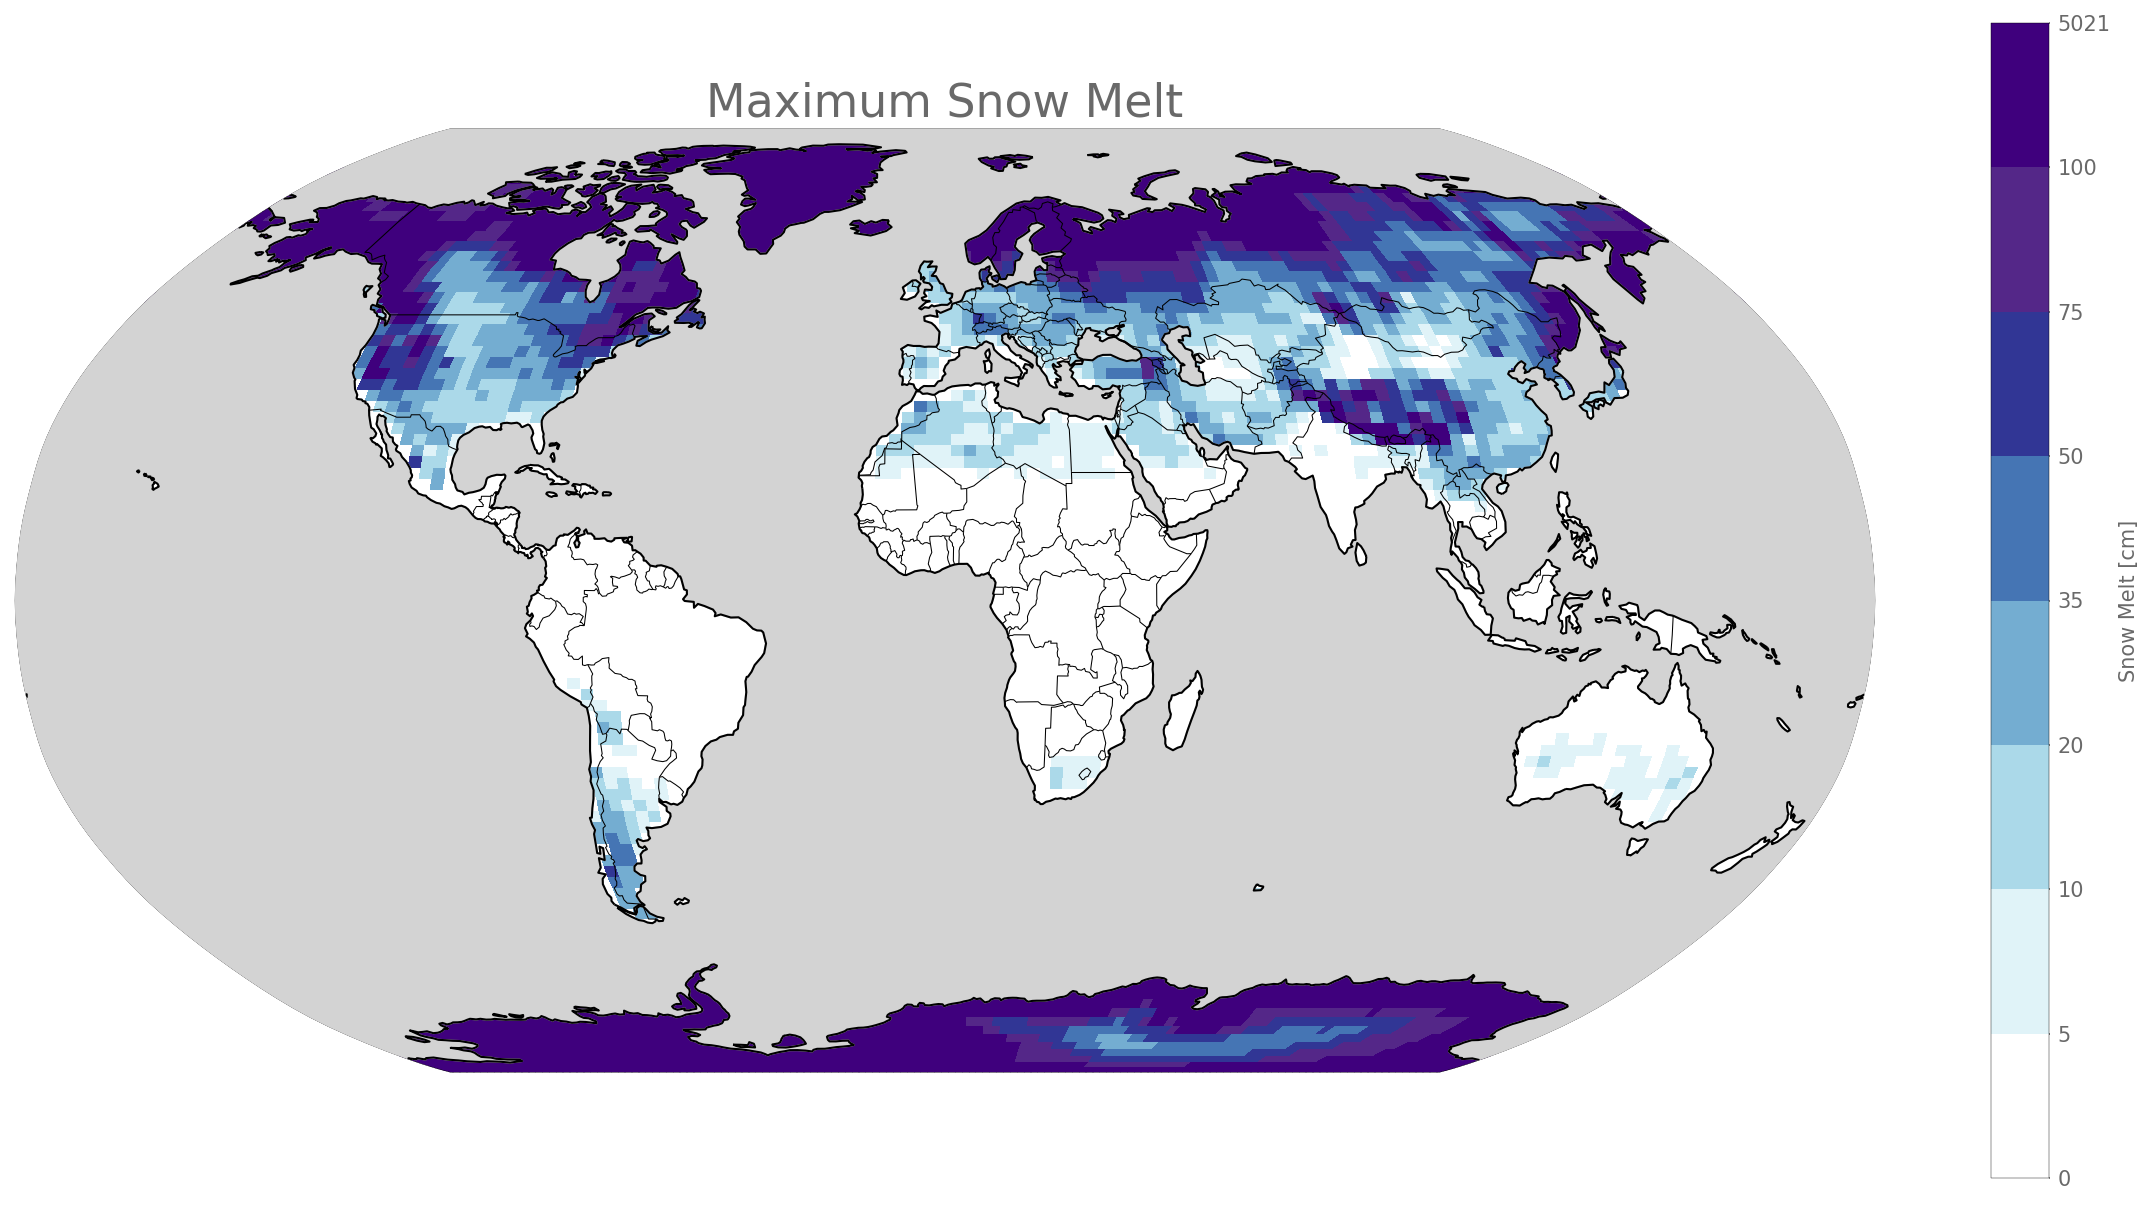

<class 'cartopy.mpl.geoaxes.GeoAxes'>


In [22]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors




bin_edges = np.array([0, 5, 10, 20, 35, 50, 75, 100, data.max()])

# Anzahl Klassen
n_classes = len(bin_edges) - 1

# Diskrete Colormap erzeugen
#cmap = plt.get_cmap("YlGnBu", n_classes)
colors = [
    #"#006400", #0 - 0.1
    "#ffffff",  # 0–100        weiß
    "#e0f3f8",  # 100–1 000    sehr hellblau
    "#abd9e9",  # 1 000–2 000  hellblau
    "#74add1",  # 2 000–3 000  mittelblau
    "#4575b4",  # 3 000–4 000  dunkelblau
    "#313695",  # 4 000–6 000  sehr dunkelblau
    "#542788",  # 6 000–10 000 blau-lila
    "#3f007d",  # >10 000      lila
]

cmap = mcolors.ListedColormap(colors)

# Norm für Klassengrenzen
norm = mcolors.BoundaryNorm(bin_edges, ncolors=n_classes)

fig = plt.figure(figsize=(20, 10))
ax = plt.axes(projection=ccrs.Robinson())

im = data.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    add_colorbar=True,
    cbar_kwargs={
        "label": "Snow Melt [cm]",
        "ticks": bin_edges  # letzte (inf) nicht anzeigen
    }
)

ax.coastlines(zorder = 11)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder= 11)
ax.add_feature(cfeature.OCEAN, color='lightgrey', zorder=10)
ax.set_title("Maximum Snow Melt", fontsize=22)

plt.show()
print(type(ax))

#Darstellung verbessern evtl. grün als Farbe, wo nie Schnee liegt

Mit Geopandas und WinTri Projektion (Punktdaten)

Schneespeicher

In [25]:
from shapely.geometry import Point
# Generate DataFrame for GeoDataFrame
data = ds["snow_storage"].max(dim="time")
data = data /10
df = data.to_dataframe(name="snow_storage").reset_index()
# Punkte ohne Daten entfernen
df = df.dropna()

#lon korrigieren, falls nötig
if df["lon"].max() > 180:
    df["lon"] = df["lon"].apply(lambda x: x - 360 if x > 180 else x)
    print("\nNach Korrektur:")
    print("Longitude min:", df["lon"].min())
    print("Longitude max:", df["lon"].max())

#Geometrie-Punkte erstellen
df["geometry"] = df.apply(lambda row: Point(row["lon"], row["lat"]), axis=1)

# in GeoDataFrame umwandeln
gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")


Nach Korrektur:
Longitude min: -177.5
Longitude max: 180.0


In [39]:
#Funktion aus Seaweed Paper angepasst
import matplotlib.colors as mcolors

def cluster_spatial(growth_df):
    """
    Creates a spatial plot of the clusters
    Arguments:
        growth_df: a dataframe of the growth rate
        global_or_US: a string of either "global" or "US" that indicates the scale
    Returns:
        None, but saves the plot
    """
    # Define the colors you want to use
    # Define a list of three colors that starts with #3A913F and gets 30 % lighter with each step
    colors = [
    "#ffffff",  # 0–10
    "#e0f3f8",  # 10–100
    "#abd9e9",  # 100–200
    "#74add1",  # 200–300
    "#4575b4",  # 300–400
    "#313695",  # 400–600
    "#542788",  # 600–1000
    "#3f007d",  # >1000
]
    # Create the colormap using the colors and the position values
    bin_edges = np.array([0, 10, 100, 200, 300, 400, 600, 1000, gdf["snow_storage"].max()])
    n_classes = len(bin_edges) - 1
    custom_map = mcolors.LinearSegmentedColormap.from_list("custom", colors, N=len(colors))
    norm = mcolors.BoundaryNorm(bin_edges, ncolors=n_classes)

    print("Plotting cluster spatial")
    growth_df = growth_df.loc[:, ["snow_storage", "geometry"]]
    global_ocean = gpd.read_file(
        "/Users/ericwostenberg/Documents/GitHub/snow_storage_and_snowmelt_in_nuclear_winter/data/test_abbildung/ne_110m_ocean/ne_110m_ocean.shp"
    )
    global_countries = gpd.read_file(
        "/Users/ericwostenberg/Documents/GitHub/snow_storage_and_snowmelt_in_nuclear_winter/data/test_abbildung/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp"
    )
    growth_df.set_crs(epsg=4326, inplace=True)
    growth_df.to_crs(global_ocean.crs, inplace=True)
    ax = growth_df.plot(column="snow_storage", legend=True,cmap=custom_map,norm=norm, markersize = 8, rasterized=True, marker = 's') #marker = square, rasterized um Dateigröße zu reduzieren
    fig = plt.gcf()
    fig.set_size_inches(12, 12)
    global_ocean.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.2)
    global_countries.plot(ax=ax, color="none", edgecolor="black", linewidth=0.2)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_ylim(-75, 85)
    ax.set_xlim(-180, 180)

Plotting cluster spatial


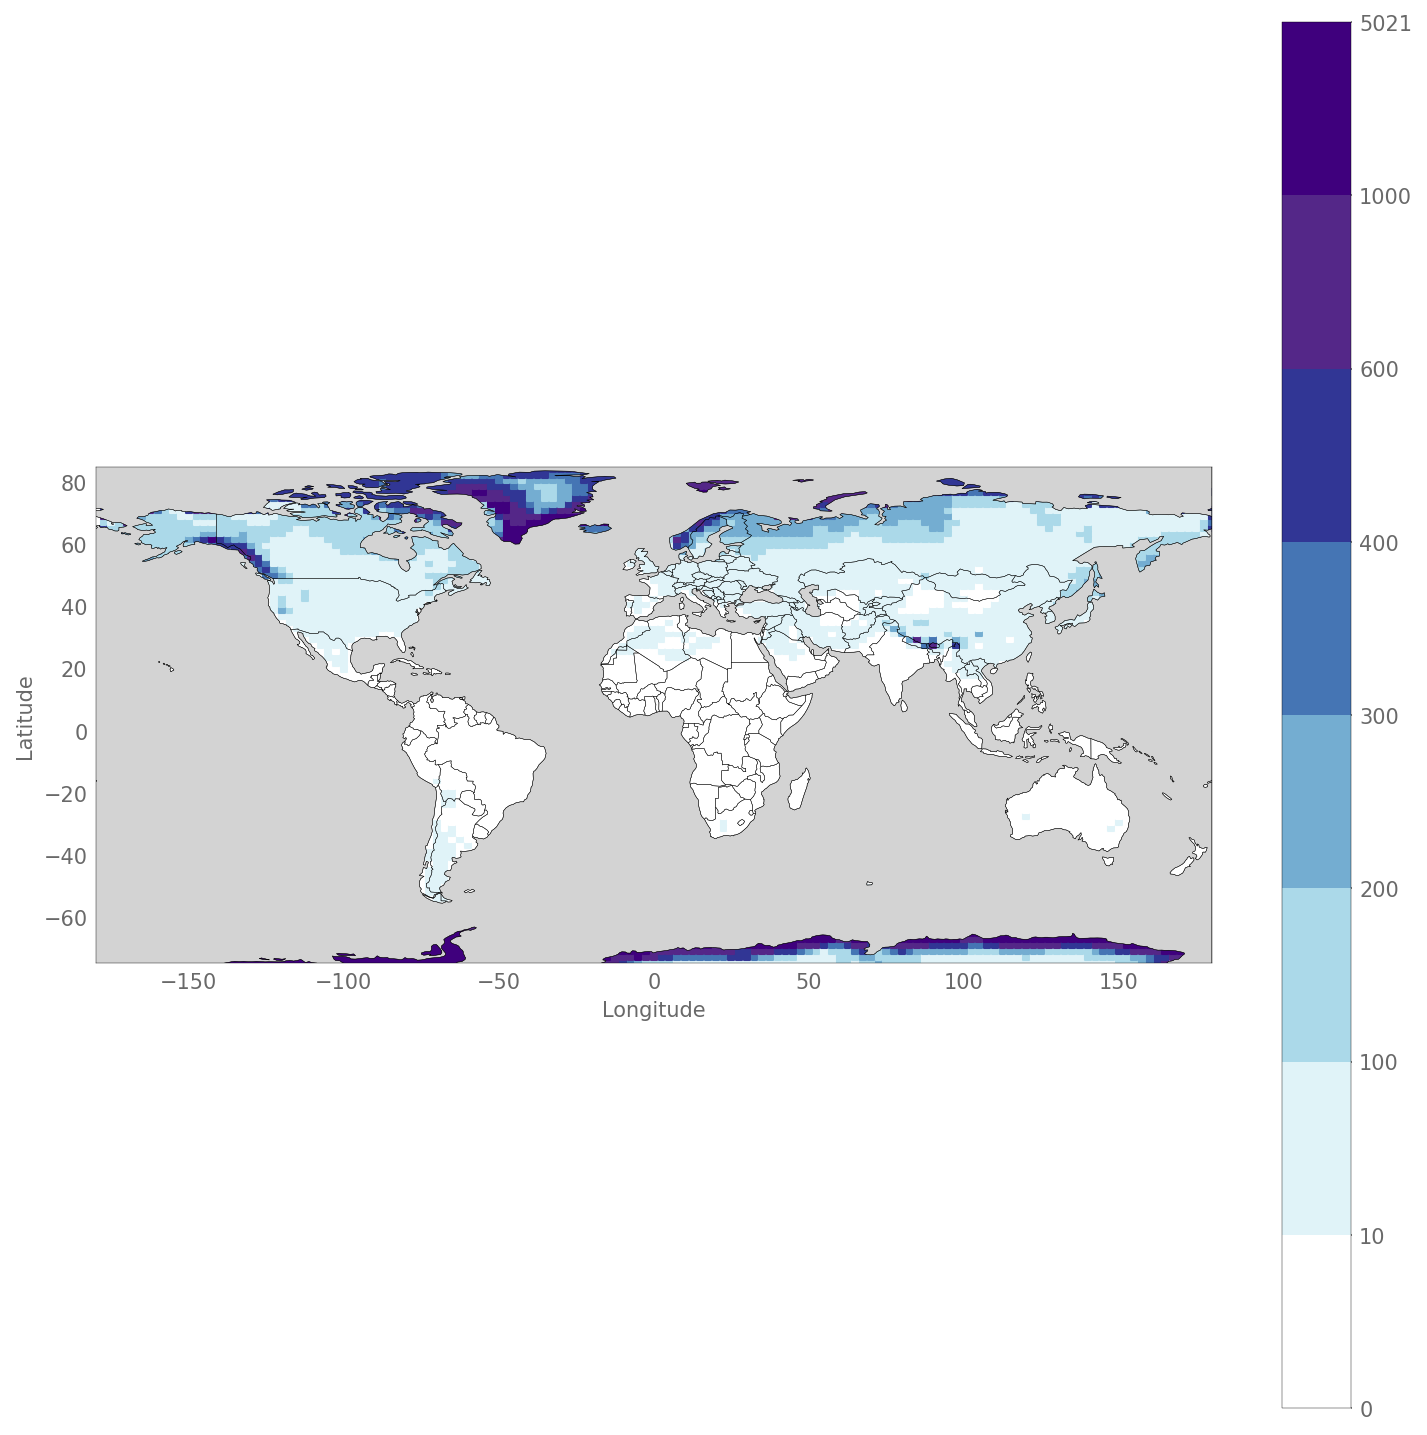

In [40]:
cluster_spatial(gdf)

gleiche Funktion aber mit Winkeltripel projektion 

In [ ]:

def cluster_spatial(growth_df):
    """
    Creates a spatial plot of the clusters in Winkel Tripel projection
    Arguments:
        growth_df: a GeoDataFrame with snow_storage and geometry columns
    Returns:
        None, but displays the plot
    """
    # Define the colors
    plt.style.use("https://raw.githubusercontent.com/allfed/ALLFED-matplotlib-style-sheet/main/ALLFED.mplstyle")
    colors = [
        "#ffffff",  # 0–10
        "#e0f3f8",  # 10–100
        "#abd9e9",  # 100–200
        "#74add1",  # 200–300
        "#4575b4",  # 300–400
        "#313695",  # 400–600
        "#542788",  # 600–1000
        "#3f007d",  # >1000
    ]
    
    # Colormap und Norm erstellen
    bin_edges = np.array([0, 10, 100, 200, 300, 400, 600, 1000, growth_df["snow_storage"].max()])
    n_classes = len(bin_edges) - 1
    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(bin_edges, ncolors=n_classes)

    print("Plotting cluster spatial")
    
    # Daten vorbereiten
    growth_df = growth_df.loc[:, ["snow_storage", "geometry"]].copy()

    
    # CRS setzen (WGS84) und zu Winkel-Tripel transformieren
    growth_df.set_crs(epsg=4326, inplace=True)
    growth_df = growth_df.to_crs('+proj=wintri')
    print(len(growth_df))
    
    # Ozean laden und zu Winkel-Tripel transformieren
    global_ocean = gpd.read_file(
        "/Users/ericwostenberg/Documents/GitHub/snow_storage_and_snowmelt_in_nuclear_winter/data/test_abbildung/ne_110m_ocean/ne_110m_ocean.shp"
    )
    global_ocean = global_ocean.to_crs('+proj=wintri')
    # Punkte clippen, die außerhalb der Ozeangrenzen liegen
    bounds = global_ocean.total_bounds
    growth_df = growth_df.cx[bounds[0]:bounds[2], bounds[1]:bounds[3]]
    print(len(growth_df))
    global_countries = gpd.read_file(
        "/Users/ericwostenberg/Documents/GitHub/snow_storage_and_snowmelt_in_nuclear_winter/data/test_abbildung/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp"
    )
    global_countries = global_countries.to_crs('+proj=wintri')
    
    # Plot erstellen
    ax = growth_df.plot(column="snow_storage", legend=True, cmap=cmap, norm=norm, rasterized=True, marker='s', markersize=13)
    fig = plt.gcf()
    fig.set_size_inches(12, 12)

    global_ocean.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.4)
    global_countries.plot(ax=ax, color="none", edgecolor="black", linewidth=0.2)
    # Achsen ausblenden (bei Winkel-Tripel keine kartesischen Achsen sinnvoll)
    # Nach dem Plotten, vor plt.show():
    ax.set_xlim(global_ocean.total_bounds[0], global_ocean.total_bounds[2])
    ax.set_ylim(global_ocean.total_bounds[1], global_ocean.total_bounds[3])

    

    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
  

Plotting cluster spatial
6240
5909


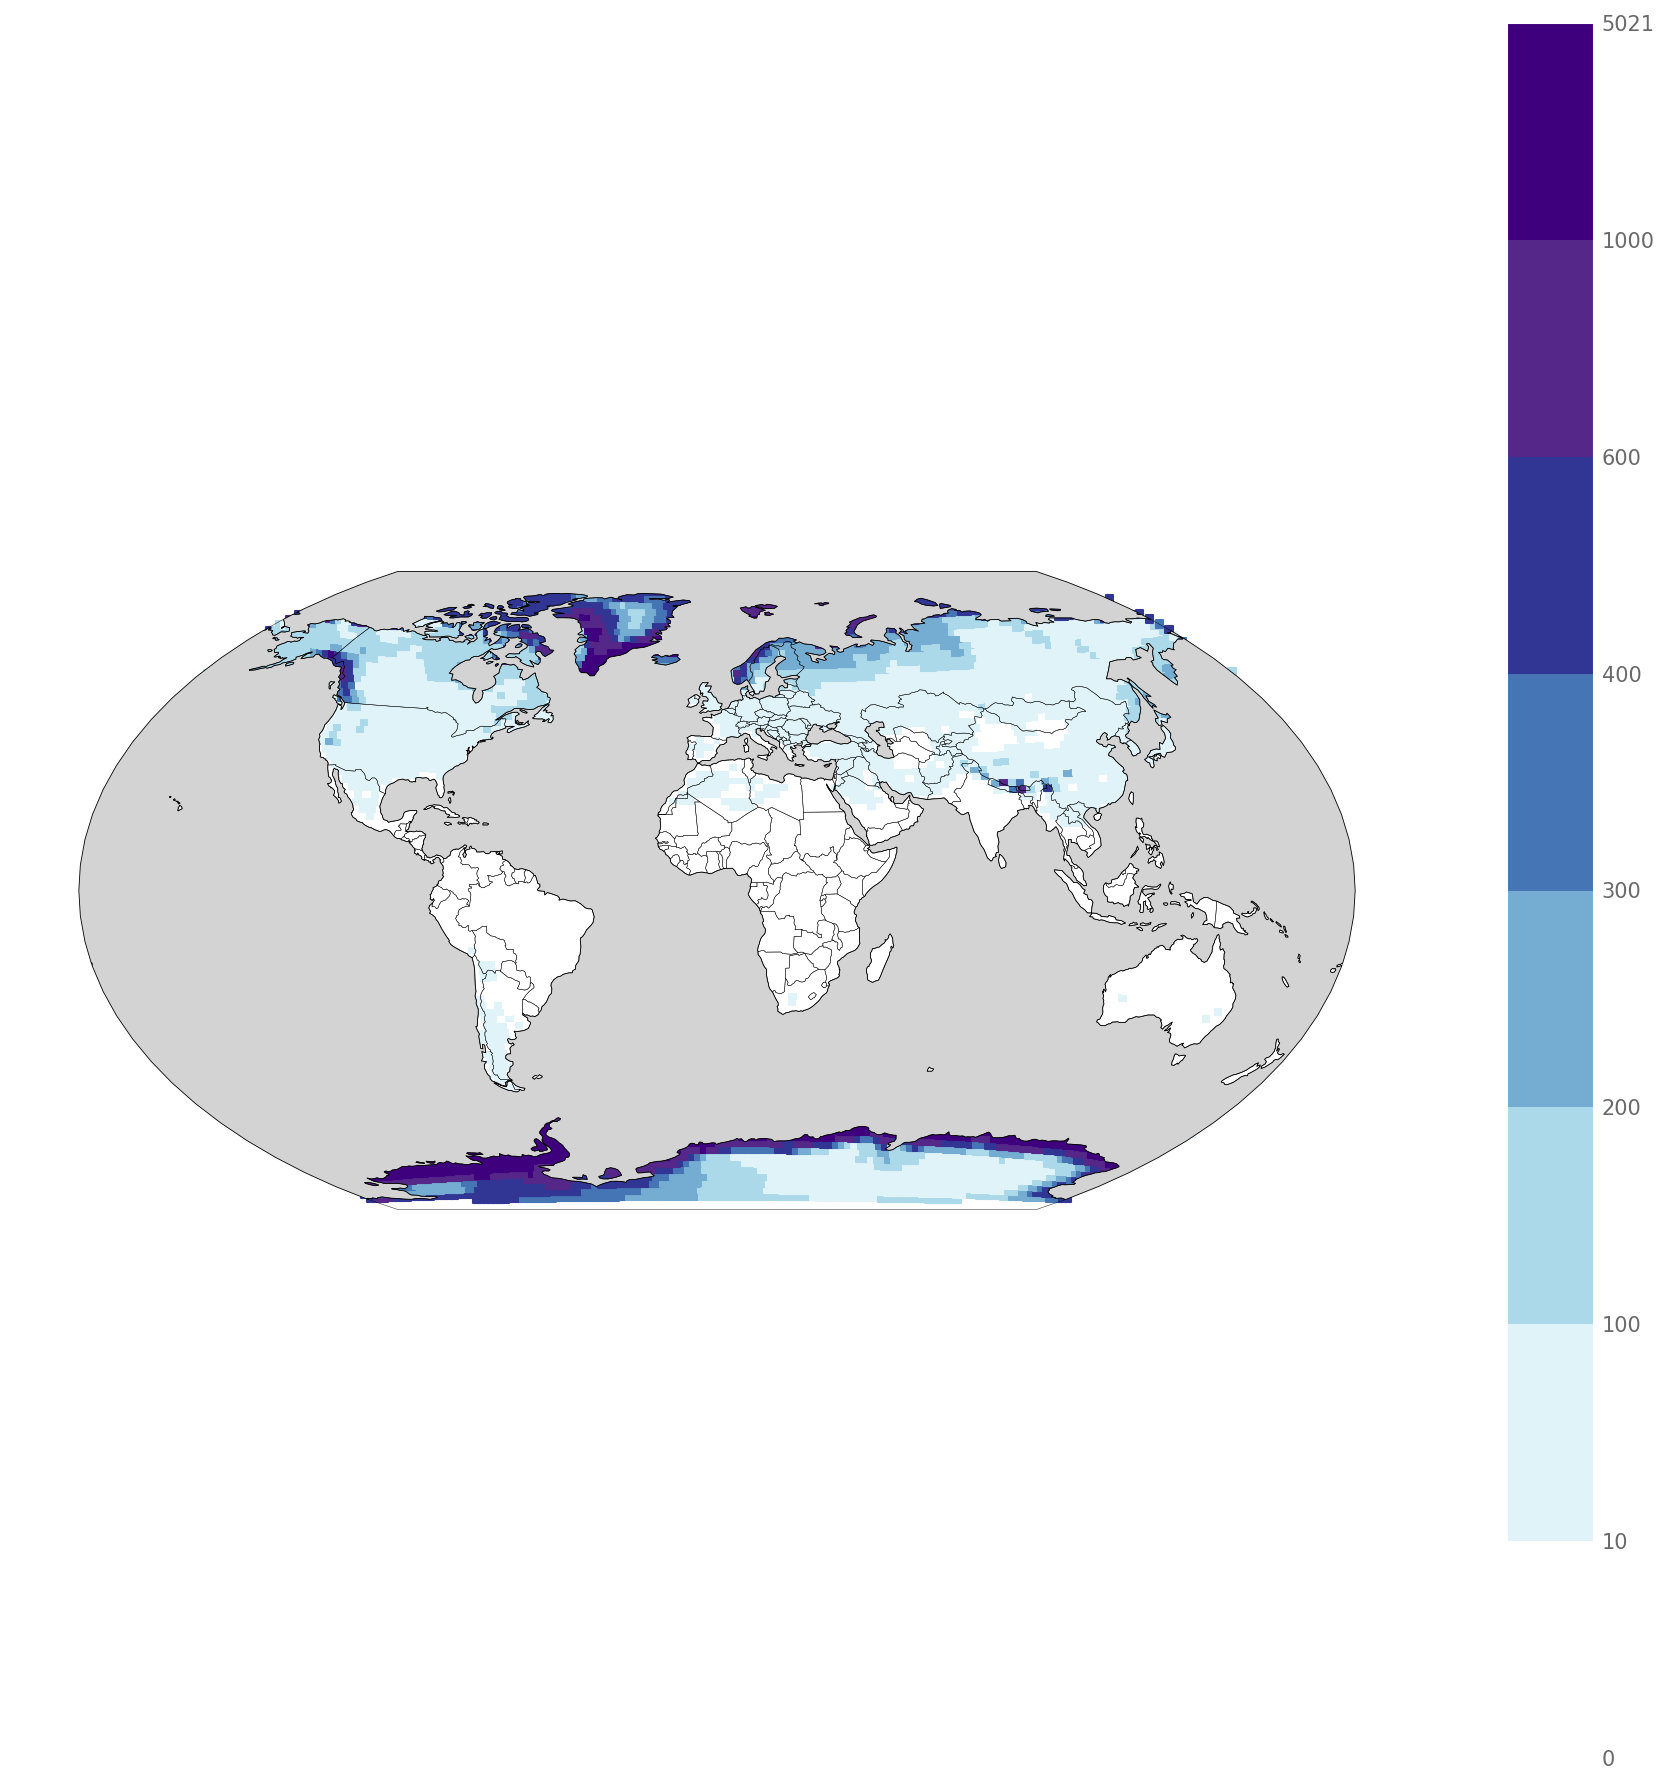

In [96]:
cluster_spatial(gdf)

Timeseries Analyse

In [64]:
da = ds.snow_storage
timeseries = clustering.prepare_time_series(da)
timeseries.shape


(6240, 360)

In [53]:
# 20% zufällige Stichprobe
subset_size = int(0.2 * 6240)  # ca. 1248 Reihen
indices = np.random.choice(6240, subset_size, replace=False)
print(indices)
timeseries_subset = timeseries[indices]  # X = (6240, 360)
print(timeseries_subset.shape)
timeseries_subset_180 = timeseries_subset[:,0:180]
print(timeseries_subset_180.shape)

[3113  941 2306 ... 3124  173 3009]
(1248, 360)
(1248, 180)


In [54]:
from datetime import datetime
def elbow_method(data, max_clusters):
    """
    Finds the optimal number of clusters using the elbow method
    https://predictivehacks.com/k-means-elbow-method-code-for-python/
    Arguments:
        data: pandas.DataFrame
        max_clusters: int - the maximum number of clusters to try (inclusive)
    Returns:
        inertias_df: DataFrame with inertias for each k
    """
    import pickle
    import numpy as np
    import pandas as pd
    import os
    
    # Pfad zur Checkpoint-Datei
    checkpoint_path = os.path.join("results","clustering", "snow_storage", "elbow_method", "inertias_.csv")
    
    # Erstelle Verzeichnis für Cluster-Ergebnisse falls nicht vorhanden
    cluster_results_dir = os.path.join("results", "clustering", "snow_storage", "elbow_method")
    os.makedirs(cluster_results_dir, exist_ok=True)
    
    # Lade bestehende Ergebnisse falls vorhanden
    if os.path.exists(checkpoint_path):
        print(f"Lade bestehende Ergebnisse aus {checkpoint_path}")
        inertias_df = pd.read_csv(checkpoint_path, sep=";", index_col=0)
        inertias = inertias_df.to_dict()[inertias_df.columns[0]]
        # Konvertiere Keys zu int
        inertias = {int(k): v for k, v in inertias.items()}
        print(f"Bereits berechnet: k = {sorted(inertias.keys())}")
    else:
        inertias = {}
    
    # Find the optimal number of clusters
    for i in range(2, max_clusters + 1):  # +1 damit max_clusters inklusiv ist!
        if i in inertias:
            print(f"k={i} bereits berechnet, überspringe...")
            continue
        
        print(f"\n{'='*60}")
        begin = datetime.now()
        print(f"{begin.strftime('%H:%M:%S')} - Trying {i} clusters")
        print(f"{'='*60}")
        
        labels, km = clustering.time_series_analysis(data, i)
        inertias[i] = km.inertia_
        print(f"✓ k={i} fertig! Inertia: {km.inertia_:.2f}")
        
        # Speichere Labels und Modell
        labels_path = os.path.join(cluster_results_dir, f'{i}_cluster_labels.npy')
        model_path = os.path.join(cluster_results_dir, f'kmeans_model_{i}.pkl')
        
        np.save(labels_path, labels)  # Labels als NumPy-Array
        print(f"→ Labels gespeichert: {labels_path}")
        
        with open(model_path, 'wb') as f:
            pickle.dump(km, f)  # Modell mit pickle
        print(f"→ Modell gespeichert: {model_path}")
        
        # Speichere Inertias nach jedem k
        inertias_df = pd.DataFrame.from_dict(
            inertias, 
            orient="index", 
            columns=["inertia"]
        )
        print("schreibe CSV")
        inertias_df.index.name = "k"
        inertias_df.to_csv(checkpoint_path, sep=";")
        print(f"→ Inertias gespeichert: {checkpoint_path}\n")
        print(f"fertig um {datetime.now().strftime('%H:%M:%S')}")
    
    print(f"\n{'='*60}")
    print("Alle Cluster fertig berechnet!")
    print(f"{'='*60}")
    
    return inertias_df

In [55]:
result = elbow_method(timeseries_subset_180, 11)


11:58:50 - Trying 2 clusters


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 792 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 1248 out of 1248 | elapsed:    2.4s finished
/Users/ericwostenberg/Documents/GitHub/snow_storage_and_snowmelt_in_nuclear_winter/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 192 tasks      | 

0.935 --> 

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 792 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 1242 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done 1792 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done 2442 tasks      | elapsed:    4.2s
[Parallel(n_jobs=-1)]: Done 2496 out of 2496 | elapsed:    4.3s finished


0.281 --> 

...

0.030 --> 


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 792 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 1242 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done 1792 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done 2442 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done 3192 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done 4042 tasks      | elapsed:    7.3s
[Parallel(n_jobs=-1)]: Done 4992 tasks      | elapsed:    8.9s
[Parallel(n_jobs=-1)]: Done 6042 tasks      | elapsed:   10.6s
[Parallel(n_jobs=-1)]: Done 7192 tasks      | elapsed:   13.1s
[Parallel(n_jobs=-1)]: Done 8442 tasks      | elapsed:   15.5s
[Parallel(n_jobs=-1)]: Done 9792 tasks      | elapsed:   19.4s
[Parallel(n_jobs=-1)]: Done 11232 out of 

✓ k=9 fertig! Inertia: 0.03
→ Labels gespeichert: results/clustering/snow_storage/elbow_method/9_cluster_labels.npy
→ Modell gespeichert: results/clustering/snow_storage/elbow_method/kmeans_model_9.pkl
schreibe CSV
→ Inertias gespeichert: results/clustering/snow_storage/elbow_method/inertias_.csv

fertig um 14:47:20

14:47:20 - Trying 10 clusters


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 792 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 1248 out of 1248 | elapsed:    2.2s finished
/Users/ericwostenberg/Documents/GitHub/snow_storage_and_snowmelt_in_nuclear_winter/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 192 tasks      | 

KeyboardInterrupt: 

In [56]:
#result = elbow_method(timeseries_subset_180, 11)
result = pd.read_csv("results/clustering/snow_storage/elbow_method/inertias_.csv", sep=";", index_col=0)

result


,inertia
k,
2,0.259989
3,0.124248
4,0.093900
5,0.079588
6,0.068029
7,0.047359
8,0.036598
9,0.030446


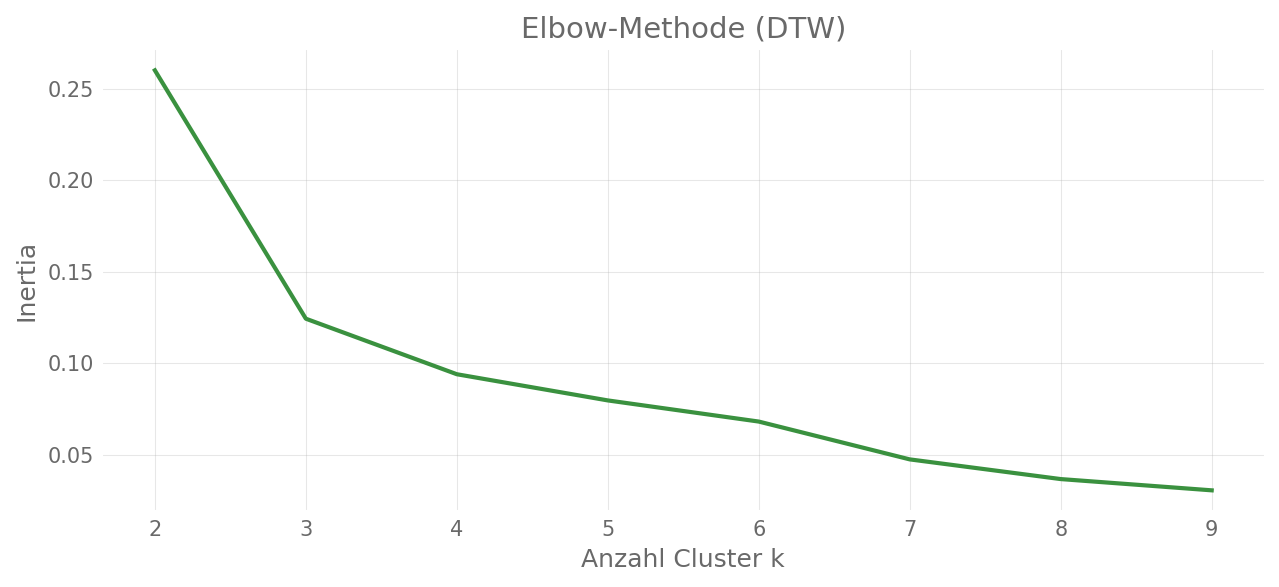

In [57]:
plt.plot(result.index, result['inertia'], linewidth=2, markersize=8)
plt.xlabel("Anzahl Cluster k", fontsize=12)
plt.ylabel("Inertia", fontsize=12)
plt.title("Elbow-Methode (DTW)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

In [63]:
from tslearn.clustering import silhouette_score
# Silhouette Scores berechnen
timeseries_subset_180

scaler = MinMaxScaler()
timeseries_scaled = scaler.fit_transform(timeseries_subset_180)


In [59]:
scores = {}
for i in range(2, 12):
    print(f'Starte {i} Cluster')
    labels = np.load(f'./results/clustering/snow_melt/elbow_method/{i}_cluster_labels.npy')
    score = silhouette_score(
    X=timeseries_scaled,        # Shape: (n_samples, n_timestamps, n_features)
    labels=labels,
    metric="euclidean",
    n_jobs=-1,
    verbose=1,
    random_state=42
    )
    scores[i] = score 



    



Starte 2 Cluster
Starte 3 Cluster
Starte 4 Cluster
Starte 5 Cluster
Starte 6 Cluster
Starte 7 Cluster
Starte 8 Cluster
Starte 9 Cluster
Starte 10 Cluster
Starte 11 Cluster


In [60]:
import pandas as pd
silhouette_scores_df = pd.DataFrame.from_dict(
            scores, 
            orient="index", 
            columns=["score"]
        )

In [61]:
silhouette_scores_df

,score
2,0.058060
3,-0.013816
4,-0.089700
5,-0.072979
6,-0.128168
7,-0.354681
8,-0.059410
9,-0.158327
10,-0.161551
11,-0.174587


Text(0, 0.5, 'Silhouette-Score')

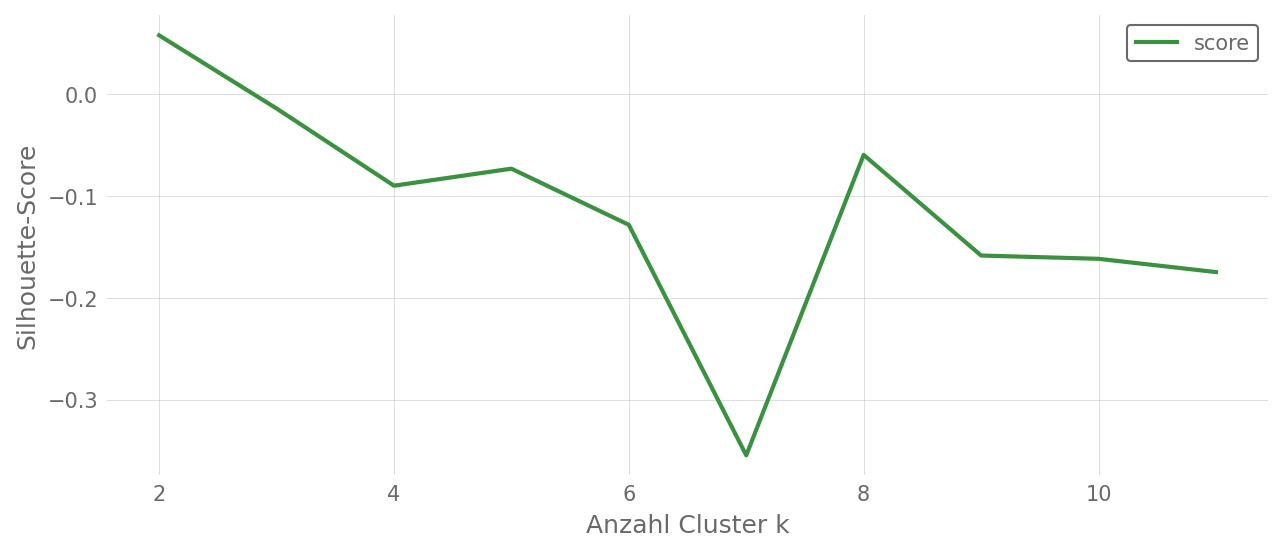

In [62]:
plt.style.use("https://raw.githubusercontent.com/allfed/ALLFED-matplotlib-style-sheet/main/ALLFED.mplstyle")
silhouette_scores_df.plot()
plt.xlabel("Anzahl Cluster k", fontsize=12)
plt.ylabel("Silhouette-Score", fontsize=12)

In [65]:
# Rechnung mit 6 Clustern
labels, km = clustering.time_series_analysis(timeseries, 3)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done 792 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 1242 tasks      | elapsed:    4.4s
[Parallel(n_jobs=-1)]: Done 1792 tasks      | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done 2442 tasks      | elapsed:    8.5s
[Parallel(n_jobs=-1)]: Done 3192 tasks      | elapsed:   11.1s
[Parallel(n_jobs=-1)]: Done 4042 tasks      | elapsed:   13.8s
[Parallel(n_jobs=-1)]: Done 4992 tasks      | elapsed:   16.8s
[Parallel(n_jobs=-1)]: Done 6042 tasks      | elapsed:   20.7s
[Parallel(n_jobs=-1)]: Done 6240 out of 6240 | elapsed:   21.2s finished
/Users/ericwostenberg/Documents/GitHub/snow_storage_and_snowmelt_in_nuclear_winter/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:95: Future

1.088 --> 

KeyboardInterrupt: 

In [ ]:
np.save('./results/clustering/snow_storage/labels_3_clusters_tol_1e-6.npy', labels)  # Labels als NumPy-Array
with open('./results/clustering/snow_melt/kmeans_model_3_clusters_tol_1e-6.pkl', 'wb') as f:
    pickle.dump(km, f)  # Modell mit pickle

In [160]:
da

<xarray.DataArray 'snow_melt' (time: 360, lat: 96, lon: 144)>
[4976640 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 -90.0 -88.11 -86.21 -84.32 ... 84.32 86.21 88.11 90.0
  * lon      (lon) float64 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) object 0005-02-01 00:00:00 ... 0035-01-01 00:00:00
Attributes:
    units:        mm month-1
    description:  Monthly snowmelt
    long_name:    Snow melt

In [164]:
np.unique(labels)

array([0, 1, 2, 3, 4, 5])

In [ ]:
template = da.isel(time=0)

# Leeres Raster
cluster_map = xr.full_like(template, fill_value=np.nan)
landmask = ~np.isnan(da.isel(time=0))
cluster_map.values[landmask.values] = labels


array([0., 1., 2., 3.], dtype=float32)

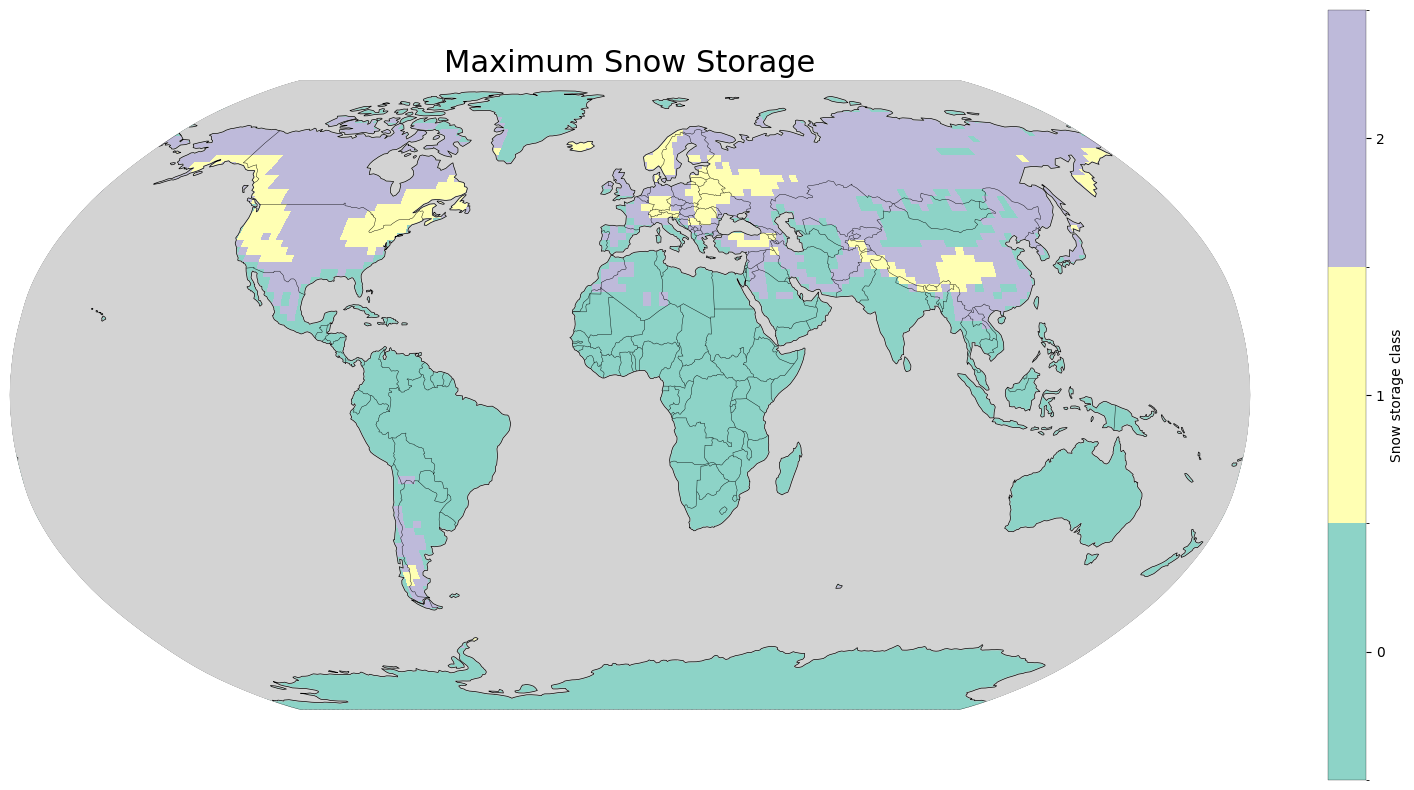

In [8]:

template = da.isel(time=0)

# Leeres Raster
cluster_map = xr.full_like(template, fill_value=np.nan)
land_mask = ~np.isnan(da.isel(time=0))
cluster_map.values[land_mask.values] = labels

data = cluster_map

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

plt.rcParams.update({
    "axes.edgecolor": "black",
    "axes.linewidth": 0.2,
})

# ===== KONFIGURATION =====
# Farbpalette
colors_full = ['#8dd3c7','#ffffb3','#bebada','#fb8072','#80b1d3','#fdb462','#b3de69','#fccde5','#d9d9d9']

# Extrahiere eindeutige Klassen aus den xarray-Daten
unique_classes = np.unique(data.values[~np.isnan(data.values)])  # Ignoriere NaN
unique_classes = np.sort(unique_classes).astype(int)  # Sortieren und zu int
n_classes = len(unique_classes)

# Wähle entsprechende Anzahl Farben
colors = colors_full[:n_classes]

# Erstelle Colormap für diskrete Klassen
cmap = mcolors.ListedColormap(colors)

# Bounds für diskrete Klassen
bounds = np.arange(unique_classes[0] - 0.5, unique_classes[-1] + 1.5, 1)
norm = mcolors.BoundaryNorm(bounds, ncolors=n_classes)

# ===== PLOT =====
fig = plt.figure(figsize=(20, 10))
ax = plt.axes(projection=ccrs.Robinson())

im = data.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    add_colorbar=True,
    cbar_kwargs={
        "label": "Snow storage class",
        "ticks": unique_classes,
        "spacing": "proportional"
    }
)

ax.coastlines(linewidth=0.5, zorder=11)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, zorder=11)
ax.add_feature(cfeature.OCEAN, color='lightgrey', zorder=10)
ax.set_title("Maximum Snow Storage", fontsize=22)

plt.show()


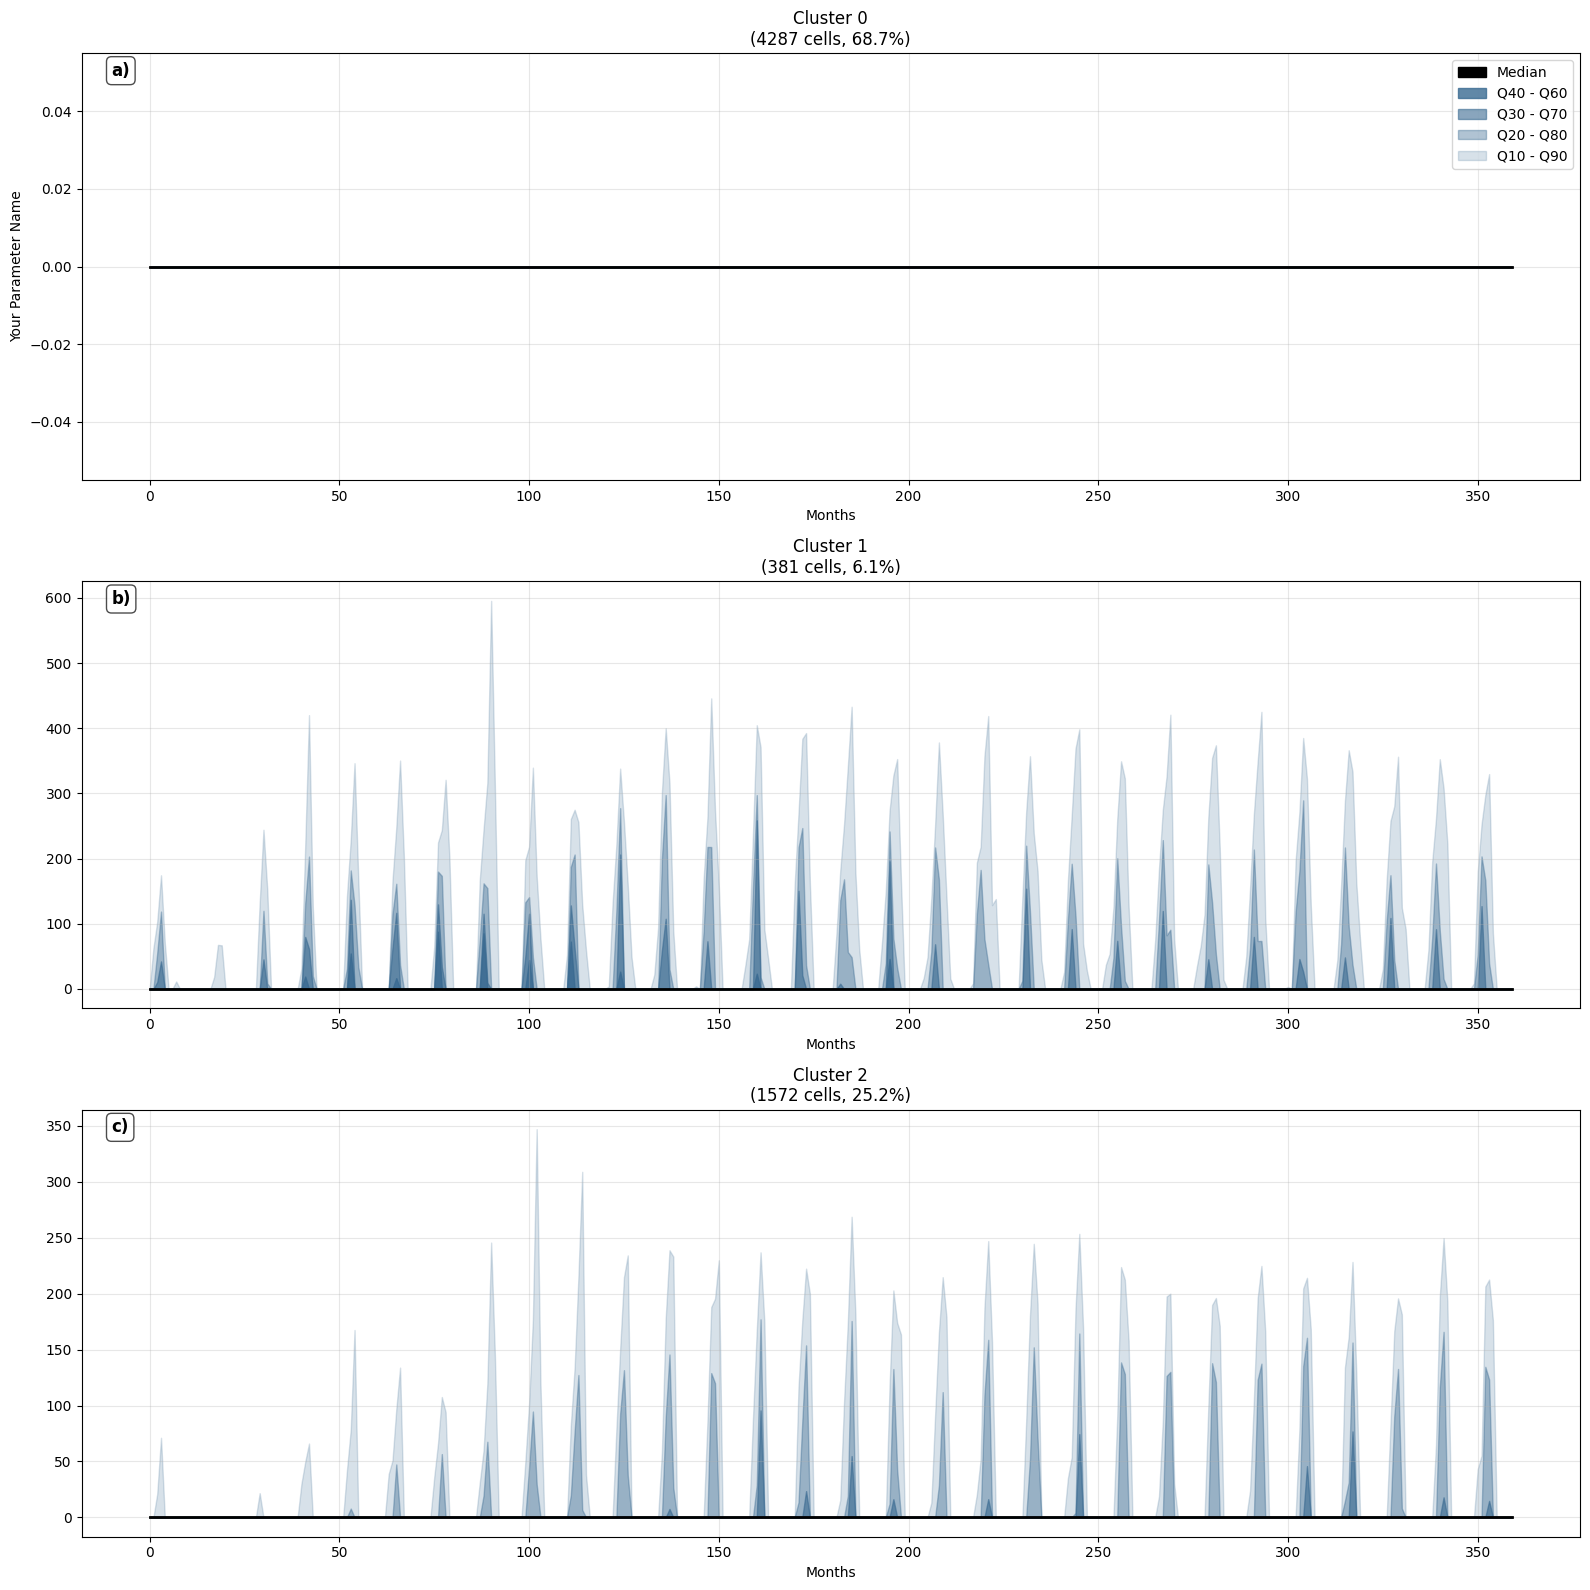

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_cluster_timeseries(
    timeseries: np.ndarray,  # shape: (n_land_cells, 360)
    labels: np.ndarray,      # shape: (n_land_cells,)
    n_clusters: int = 4,
    parameter_name: str = "Parameter"
):
    """
    Plots time series for all clusters with quantile bands
    
    Arguments:
        timeseries: np.ndarray, shape (n_land_cells, 360) - normalized time series
        labels: np.ndarray, shape (n_land_cells,) - cluster assignments
        n_clusters: int - number of clusters
        parameter_name: str - name of the parameter being plotted
    """
    fig, axes = plt.subplots(
        nrows=n_clusters, ncols=1, sharey=False, sharex=False, figsize=(16, 16)
    )
    
    # Falls nur 1 Cluster (sollte nicht passieren), axes in Liste umwandeln
    if n_clusters == 1:
        axes = [axes]
    
    for cluster in range(n_clusters):
        # Alle Zeitreihen dieses Clusters extrahieren
        cluster_mask = labels == cluster
        cluster_ts = timeseries[cluster_mask]  # shape: (n_cells_in_cluster, 360)
        
        ax = axes[cluster]
        
        # Quantile berechnen und plotten
        for q in np.arange(0.1, 0.6, 0.1):
            q_up = np.quantile(cluster_ts, 1 - q, axis=0)
            q_down = np.quantile(cluster_ts, q, axis=0)
            
            ax.fill_between(
                x=range(360),
                y1=q_down,
                y2=q_up,
                color="#3A6A91",
                alpha=q * 2,
            )
        
        # Median plotten
        median = np.median(cluster_ts, axis=0)
        ax.plot(range(360), median, color="black", linewidth=2)
        
        # Labels und Titel
        ax.set_title(
            f"Cluster {cluster}\n({cluster_ts.shape[0]} cells, "
            f"{cluster_ts.shape[0]/len(labels)*100:.1f}%)"
        )
        ax.set_xlabel("Months")
        
        if cluster == 0:
            ax.set_ylabel(parameter_name)
            
            # Legende nur im ersten Subplot
            patches_list = []
            patches_list.append(mpatches.Patch(color="black", label="Median"))
            patches_list.append(
                mpatches.Patch(color="#3A6A91", label="Q40 - Q60", alpha=0.8)
            )
            patches_list.append(
                mpatches.Patch(color="#3A6A91", label="Q30 - Q70", alpha=0.6)
            )
            patches_list.append(
                mpatches.Patch(color="#3A6A91", label="Q20 - Q80", alpha=0.4)
            )
            patches_list.append(
                mpatches.Patch(color="#3A6A91", label="Q10 - Q90", alpha=0.2)
            )
            ax.legend(handles=patches_list, loc='best')
        
        # Grid hinzufügen
        ax.grid(True, alpha=0.3)
    
    # Subplot-Labels (a), b), c), d))
    for i, ax in enumerate(axes):
        ax.text(
            0.02, 0.98,
            f"{chr(97+i)})",
            transform=ax.transAxes,
            fontsize=12,
            verticalalignment="top",
            horizontalalignment="left",
            color="black",
            weight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
        )
    
    plt.tight_layout()
    #plt.savefig("cluster_timeseries.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    #print(f"Plot saved as 'cluster_timeseries.png'")


# Verwendung:
plot_cluster_timeseries(
    timeseries=timeseries,  # Deine normalisierten Zeitreihen
    labels=labels,           # Deine Cluster-Labels
    n_clusters=3,
    parameter_name="Your Parameter Name"
)

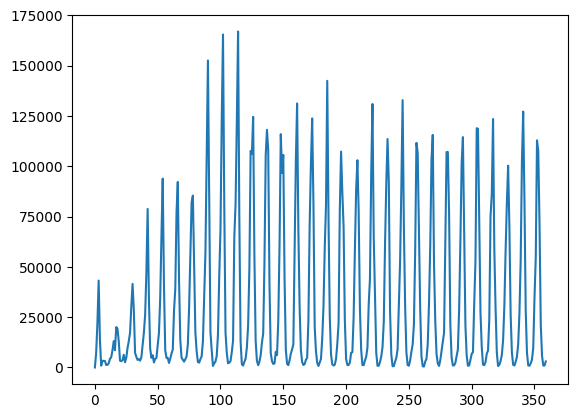

In [19]:
months = np.arange(360)

fig, ax = plt.subplots()
ax.plot(months, global_sum_per_month.values)

In [ ]:
data = ds.SS.sum(dim=['lat','lon']).values

months = np.arange(360)

fig, ax = plt.subplots()
ax.plot(months, data)

70,7



In [7]:
labels, km_model = clustering.time_series_analysis(timeseries, n_clusters=4)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 792 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 1242 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done 1792 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done 2442 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done 3192 tasks      | elapsed:    8.8s
[Parallel(n_jobs=-1)]: Done 4042 tasks      | elapsed:   11.3s
[Parallel(n_jobs=-1)]: Done 4992 tasks      | elapsed:   14.0s
[Parallel(n_jobs=-1)]: Done 6042 tasks      | elapsed:   17.6s
[Parallel(n_jobs=-1)]: Done 6240 out of 6240 | elapsed:   18.2s finished
/Users/ericwostenberg/Documents/GitHub/snow_storage_and_snowmelt_in_nuclear_winter/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:95: Future

0.665 --> 

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 792 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done 1242 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 1792 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done 2442 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done 3192 tasks      | elapsed:    8.6s
[Parallel(n_jobs=-1)]: Done 4042 tasks      | elapsed:   10.9s
[Parallel(n_jobs=-1)]: Done 4992 tasks      | elapsed:   13.4s
[Parallel(n_jobs=-1)]: Done 6042 tasks      | elapsed:   16.1s
[Parallel(n_jobs=-1)]: Done 7192 tasks      | elapsed:   18.8s
[Parallel(n_jobs=-1)]: Done 8442 tasks      | elapsed:   21.7s
[Parallel(n_jobs=-1)]: Done 9792 tasks      | elapsed:   24.9s
[Parallel(n_jobs=-1)]: Done 11242 tasks  

0.133 --> 

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 792 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done 1242 tasks      | elapsed:    3.6s
[Parallel(n_jobs=-1)]: Done 1792 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done 2442 tasks      | elapsed:    6.9s
[Parallel(n_jobs=-1)]: Done 3192 tasks      | elapsed:    9.0s
[Parallel(n_jobs=-1)]: Done 4042 tasks      | elapsed:   11.4s
[Parallel(n_jobs=-1)]: Done 4992 tasks      | elapsed:   14.2s
[Parallel(n_jobs=-1)]: Done 6042 tasks      | elapsed:   17.2s
[Parallel(n_jobs=-1)]: Done 7192 tasks      | elapsed:   20.2s
[Parallel(n_jobs=-1)]: Done 8442 tasks      | elapsed:   23.7s
[Parallel(n_jobs=-1)]: Done 9792 tasks      | elapsed:   27.5s
[Parallel(n_jobs=-1)]: Done 11242 tasks  

...

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done 792 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done 1242 tasks      | elapsed:    4.3s
[Parallel(n_jobs=-1)]: Done 1792 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-1)]: Done 2442 tasks      | elapsed:    8.4s
[Parallel(n_jobs=-1)]: Done 3192 tasks      | elapsed:   11.0s
[Parallel(n_jobs=-1)]: Done 4042 tasks      | elapsed:   13.9s
[Parallel(n_jobs=-1)]: Done 4992 tasks      | elapsed:   28.8s
[Parallel(n_jobs=-1)]: Done 6042 tasks      | elapsed:   32.0s
[Parallel(n_jobs=-1)]: Done 7192 tasks      | elapsed:   34.8s
[Parallel(n_jobs=-1)]: Done 8442 tasks      | elapsed:   38.1s
[Parallel(n_jobs=-1)]: Done 9792 tasks      | elapsed:   41.4s
[Parallel(n_jobs=-1)]: Done 11242 tasks  

0.095 --> 

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done 792 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done 1242 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done 1792 tasks      | elapsed:    5.9s
[Parallel(n_jobs=-1)]: Done 2442 tasks      | elapsed:    8.1s
[Parallel(n_jobs=-1)]: Done 3192 tasks      | elapsed:   10.6s
[Parallel(n_jobs=-1)]: Done 4042 tasks      | elapsed:   13.5s
[Parallel(n_jobs=-1)]: Done 4992 tasks      | elapsed:   16.6s
[Parallel(n_jobs=-1)]: Done 6042 tasks      | elapsed:   20.1s
[Parallel(n_jobs=-1)]: Done 7192 tasks      | elapsed:   23.5s
[Parallel(n_jobs=-1)]: Done 8442 tasks      | elapsed:   27.4s
[Parallel(n_jobs=-1)]: Done 9792 tasks      | elapsed:   43.9s
[Parallel(n_jobs=-1)]: Done 11242 tasks  

0.094 --> 


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done 792 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done 1242 tasks      | elapsed:    4.2s
[Parallel(n_jobs=-1)]: Done 1792 tasks      | elapsed:    6.0s
[Parallel(n_jobs=-1)]: Done 2442 tasks      | elapsed:    8.2s
[Parallel(n_jobs=-1)]: Done 3192 tasks      | elapsed:   10.7s
[Parallel(n_jobs=-1)]: Done 4042 tasks      | elapsed:   13.5s
[Parallel(n_jobs=-1)]: Done 4992 tasks      | elapsed:   16.7s
[Parallel(n_jobs=-1)]: Done 6042 tasks      | elapsed:   20.3s
[Parallel(n_jobs=-1)]: Done 7192 tasks      | elapsed:   24.2s
[Parallel(n_jobs=-1)]: Done 8442 tasks      | elapsed:   28.2s
[Parallel(n_jobs=-1)]: Done 9792 tasks      | elapsed:   44.8s
[Parallel(n_jobs=-1)]: Done 11242 tasks  

In [20]:
import pickle
import numpy as np

np.save('./results/clustering/4_cluster_labels.npy', labels)  # Labels als NumPy-Array
with open('./results/clustering/kmeans_model_4.pkl', 'wb') as f:
    pickle.dump(km_model, f)  # Modell mit pickle



NameError: name 'labels' is not defined

In [109]:
# Laden
labels = np.load('./results/clustering/4_cluster_labels.npy')
with open('./results/clustering/kmeans_model_4.pkl', 'rb') as f:
    km = pickle.load(f)

In [111]:
da = ds["snow_storage"]

In [ ]:

template = da.isel(time=0)

# Leeres Raster
cluster_map = xr.full_like(template, fill_value=np.nan)
land_mask = ~np.isnan(da.isel(time=0))
cluster_map.values[land_mask.values] = labels




In [ ]:
data = cluster_map


array([0., 1., 2., 3.], dtype=float32)

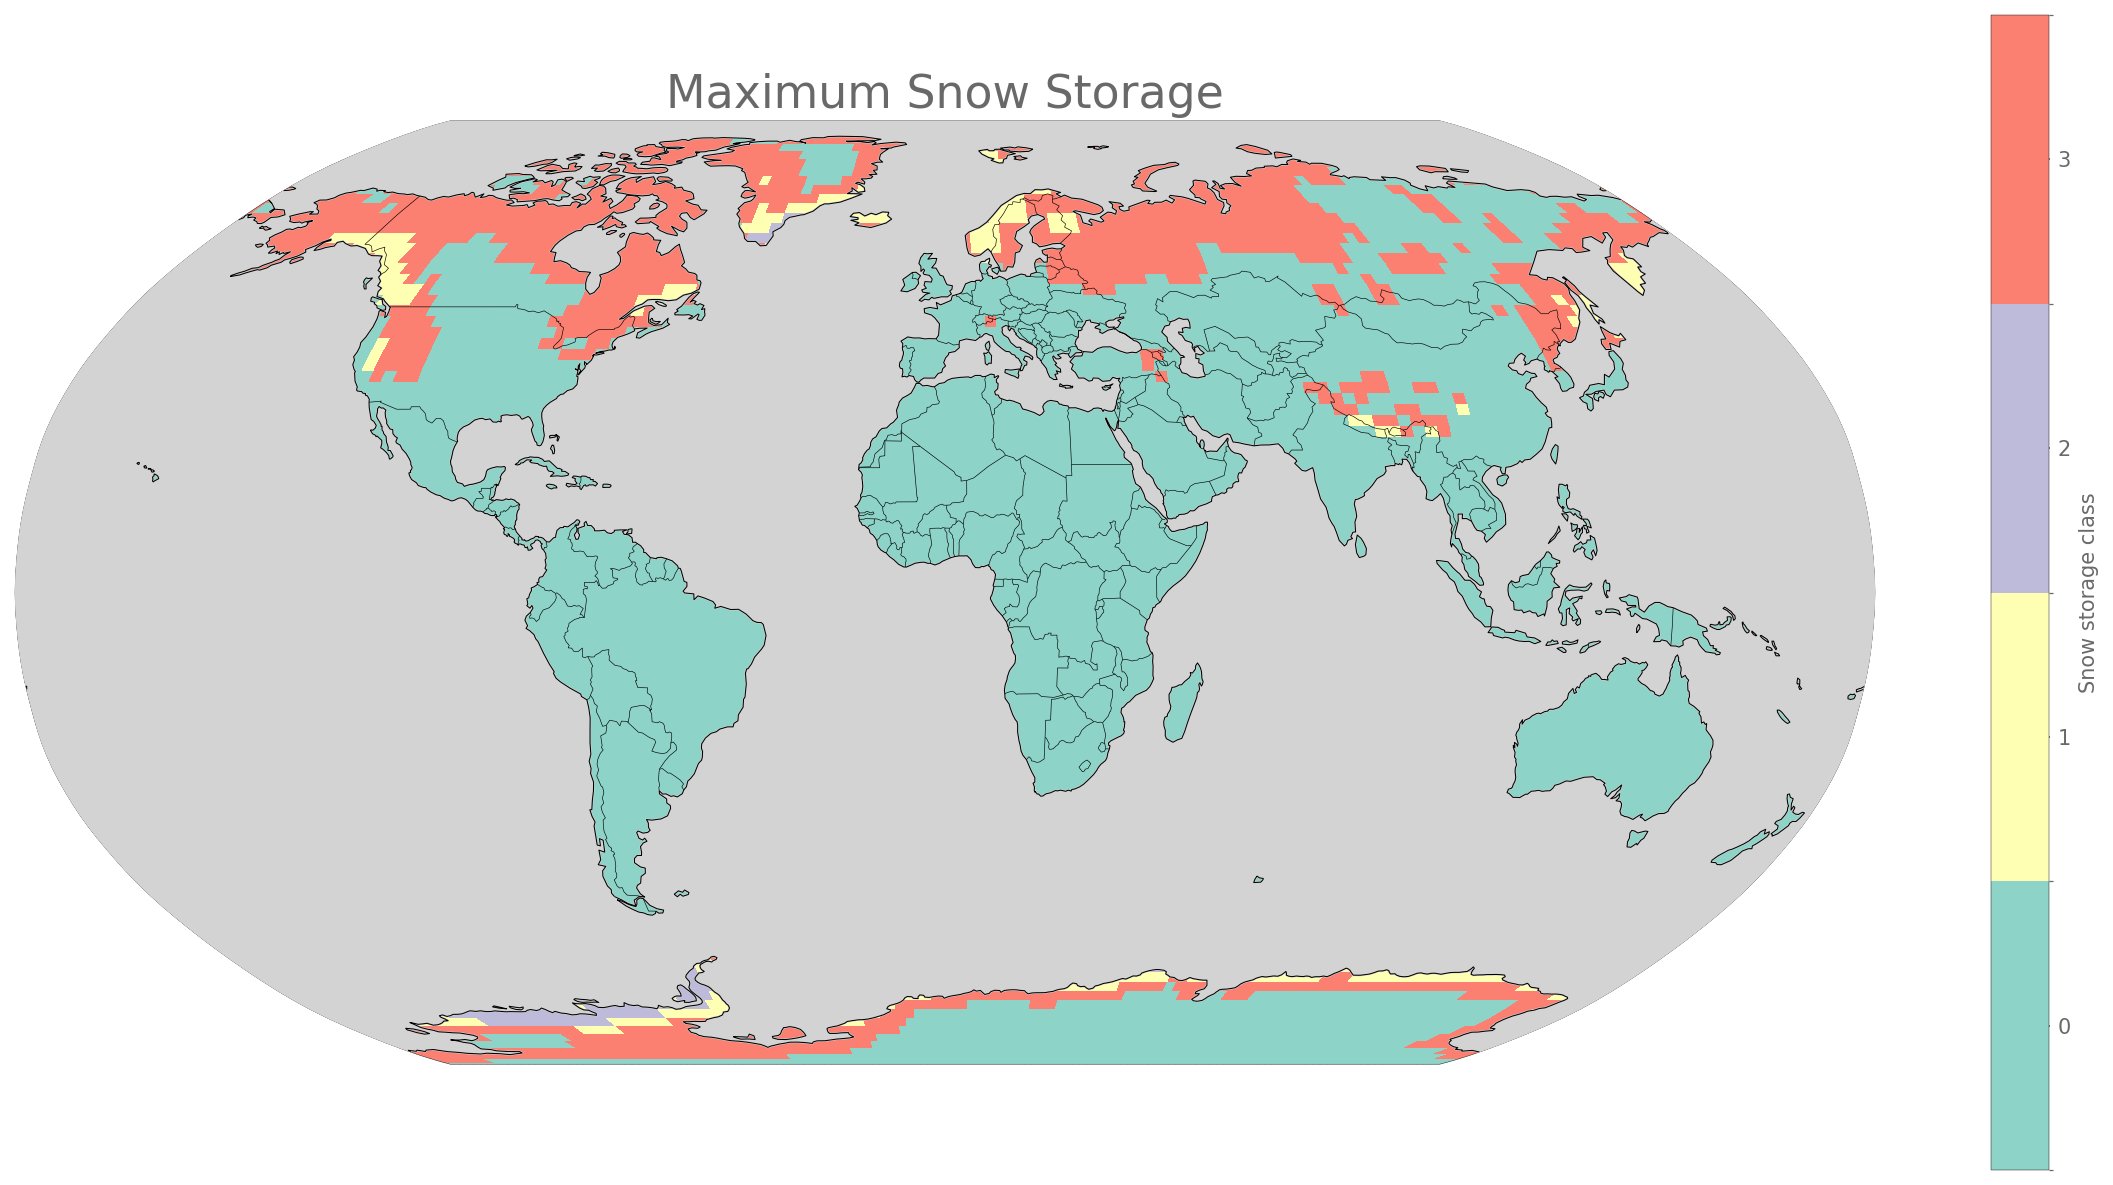

In [136]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

plt.rcParams.update({
    "axes.edgecolor": "black",
    "axes.linewidth": 0.2,
})

# ===== KONFIGURATION =====
# Farbpalette
colors_full = ['#8dd3c7','#ffffb3','#bebada','#fb8072','#80b1d3','#fdb462','#b3de69','#fccde5','#d9d9d9']

# Extrahiere eindeutige Klassen aus den xarray-Daten
unique_classes = np.unique(data.values[~np.isnan(data.values)])  # Ignoriere NaN
unique_classes = np.sort(unique_classes).astype(int)  # Sortieren und zu int
n_classes = len(unique_classes)

# Wähle entsprechende Anzahl Farben
colors = colors_full[:n_classes]

# Erstelle Colormap für diskrete Klassen
cmap = mcolors.ListedColormap(colors)

# Bounds für diskrete Klassen
bounds = np.arange(unique_classes[0] - 0.5, unique_classes[-1] + 1.5, 1)
norm = mcolors.BoundaryNorm(bounds, ncolors=n_classes)

# ===== PLOT =====
fig = plt.figure(figsize=(20, 10))
ax = plt.axes(projection=ccrs.Robinson())

im = data.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    add_colorbar=True,
    cbar_kwargs={
        "label": "Snow storage class",
        "ticks": unique_classes,
        "spacing": "proportional"
    }
)

ax.coastlines(linewidth=0.5, zorder=11)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, zorder=11)
ax.add_feature(cfeature.OCEAN, color='lightgrey', zorder=10)
ax.set_title("Maximum Snow Storage", fontsize=22)

plt.show()

In [20]:
from sklearn.preprocessing import MinMaxScaler  

In [21]:
scaler = MinMaxScaler()
timeseries_scaled = scaler.fit_transform(timeseries)

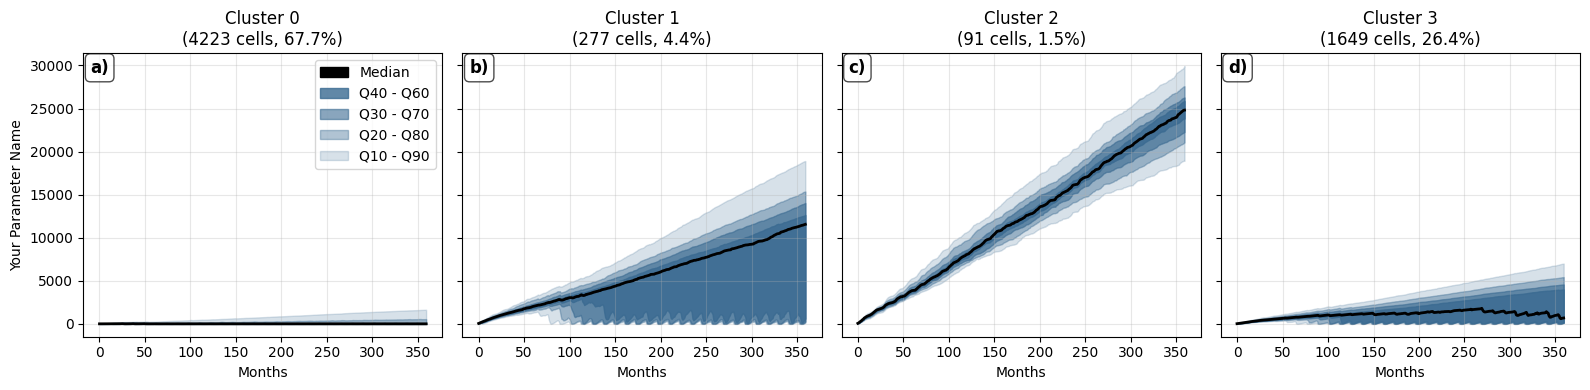

Plot saved as 'cluster_timeseries.png'


In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_cluster_timeseries(
    timeseries: np.ndarray,  # shape: (n_land_cells, 360)
    labels: np.ndarray,      # shape: (n_land_cells,)
    n_clusters: int = 4,
    parameter_name: str = "Parameter"
):
    """
    Plots time series for all clusters with quantile bands
    
    Arguments:
        timeseries: np.ndarray, shape (n_land_cells, 360) - normalized time series
        labels: np.ndarray, shape (n_land_cells,) - cluster assignments
        n_clusters: int - number of clusters
        parameter_name: str - name of the parameter being plotted
    """
    fig, axes = plt.subplots(
        nrows=1, ncols=n_clusters, sharey=True, sharex=True, figsize=(16, 4)
    )
    
    # Falls nur 1 Cluster (sollte nicht passieren), axes in Liste umwandeln
    if n_clusters == 1:
        axes = [axes]
    
    for cluster in range(n_clusters):
        # Alle Zeitreihen dieses Clusters extrahieren
        cluster_mask = labels == cluster
        cluster_ts = timeseries[cluster_mask]  # shape: (n_cells_in_cluster, 360)
        
        ax = axes[cluster]
        
        # Quantile berechnen und plotten
        for q in np.arange(0.1, 0.6, 0.1):
            q_up = np.quantile(cluster_ts, 1 - q, axis=0)
            q_down = np.quantile(cluster_ts, q, axis=0)
            
            ax.fill_between(
                x=range(360),
                y1=q_down,
                y2=q_up,
                color="#3A6A91",
                alpha=q * 2,
            )
        
        # Median plotten
        median = np.median(cluster_ts, axis=0)
        ax.plot(range(360), median, color="black", linewidth=2)
        
        # Labels und Titel
        ax.set_title(
            f"Cluster {cluster}\n({cluster_ts.shape[0]} cells, "
            f"{cluster_ts.shape[0]/len(labels)*100:.1f}%)"
        )
        ax.set_xlabel("Months")
        
        if cluster == 0:
            ax.set_ylabel(parameter_name)
            
            # Legende nur im ersten Subplot
            patches_list = []
            patches_list.append(mpatches.Patch(color="black", label="Median"))
            patches_list.append(
                mpatches.Patch(color="#3A6A91", label="Q40 - Q60", alpha=0.8)
            )
            patches_list.append(
                mpatches.Patch(color="#3A6A91", label="Q30 - Q70", alpha=0.6)
            )
            patches_list.append(
                mpatches.Patch(color="#3A6A91", label="Q20 - Q80", alpha=0.4)
            )
            patches_list.append(
                mpatches.Patch(color="#3A6A91", label="Q10 - Q90", alpha=0.2)
            )
            ax.legend(handles=patches_list, loc='best')
        
        # Grid hinzufügen
        ax.grid(True, alpha=0.3)
    
    # Subplot-Labels (a), b), c), d))
    for i, ax in enumerate(axes):
        ax.text(
            0.02, 0.98,
            f"{chr(97+i)})",
            transform=ax.transAxes,
            fontsize=12,
            verticalalignment="top",
            horizontalalignment="left",
            color="black",
            weight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
        )
    
    plt.tight_layout()
    plt.savefig("cluster_timeseries.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    print(f"Plot saved as 'cluster_timeseries.png'")


# Verwendung:
plot_cluster_timeseries(
    timeseries=timeseries,  # Deine normalisierten Zeitreihen
    labels=labels,           # Deine Cluster-Labels
    n_clusters=4,
    parameter_name="Your Parameter Name"
)

In [ ]:

km_model.cluster_centers_.plot()

AttributeError: 'numpy.ndarray' object has no attribute 'plot'

In [16]:
da_t.values[land_mask.values]

array([[4.3832545e+00, 9.8538561e+00, 1.7442749e+01, ..., 1.6775768e+03,
        1.6827485e+03, 1.6857865e+03],
       [4.3774595e+00, 9.8479586e+00, 1.7436852e+01, ..., 1.6775557e+03,
        1.6827273e+03, 1.6857653e+03],
       [4.3823838e+00, 9.8530064e+00, 1.7441900e+01, ..., 1.6775958e+03,
        1.6827676e+03, 1.6858057e+03],
       ...,
       [1.0290720e+01, 1.7900042e+01, 2.5302727e+01, ..., 4.5313623e+03,
        4.5347490e+03, 4.5446143e+03],
       [1.0251997e+01, 1.7282211e+01, 2.3955614e+01, ..., 4.3940713e+03,
        4.3976880e+03, 4.4074277e+03],
       [1.0449547e+01, 1.7266434e+01, 2.3651848e+01, ..., 4.4135952e+03,
        4.4173301e+03, 4.4274614e+03]], dtype=float32)

In [17]:
test = to_time_series_dataset(da_t)

In [18]:
test = clustering.prepare_time_series(da)

In [23]:
test[0] == da.values[:,0,0]


array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [9]:
land_mask = ~np.isnan(da.isel(time=0))




In [13]:
da_t = da.transpose("lat", "lon", "time")

In [17]:
da_t.values[land_mask.values].shape

(6240, 360)

In [11]:
X = da_t.values[land_mask.values]  # shape: (n_land_cells, time)

NameError: name 'da_t' is not defined

In [8]:
labels, km = clustering.time_series_analysis(ds.snow_storage, n_clusters = 4)

ValueError: Found array with dim 3, while dim <= 2 is required by MinMaxScaler.

In [3]:
dataset = preprocessing.run_preprocessing(
        data_directory="./data/Model_Output_From_Harrison/Temp_Precip/nw_ur_150_07",
        file_pattern="nw_ur_150_07.cam.h0.*.nc",
        output_path="./data/interim/preprocessed/climate_data_processed.nc",
    )

Loading climate data files
Found: 360 files
First file: nw_ur_150_07.cam.h0.0005-01.nc
Last file: nw_ur_150_07.cam.h0.0034-12.nc
Calculating days in each month
Calculating total monthly precipitation
Converting temperature from Kelvin to Celsius
Saving processed data to ./data/interim/preprocessed/climate_data_processed.nc


Run Snow Model

In [5]:
snow_storage, snow_melt = snow_model.calculate_snow_dynamics(dataset.precip_mm_month.values, dataset.t_mean_celsius.values, dataset.days_in_month.values)

In [ ]:
def create_output_dataset(ds_original: xr.Dataset,
                          snow_storage: np.ndarray,
                          snow_melt: np.ndarray) -> xr.Dataset:
    """
    Create output dataset with snow model results.
    
    Parameters
    ----------
    ds_original : xr.Dataset
        Original dataset (for coordinates and metadata)
    snow_storage : np.ndarray
        Snow storage results, shape (time, lat, lon)
    snow_melt : np.ndarray
        Snow melt results, shape (time, lat, lon)
        
    Returns
    -------
    xr.Dataset
        Dataset containing original data plus snow variables
    """
    # Create DataArrays for snow variables
    snow_storage_da = xr.DataArray(
        snow_storage,
        dims=("time", "lat", "lon"),
        coords={
            "time": ds_original.time,
            "lat": ds_original.lat,
            "lon": ds_original.lon
        },
        name="SS",
        attrs={
            "units": "mm",
            "long_name": "Snow water equivalent storage",
            "description": f"Calculated with degree-day snow model "
        }
    )
    
    snow_melt_da = xr.DataArray(
        snow_melt,
        dims=("time", "lat", "lon"),
        coords={
            "time": ds_original.time,
            "lat": ds_original.lat,
            "lon": ds_original.lon
        },
        name="SM",
        attrs={
            "units": "mm",
            "long_name": "Snow melt",
            "description": f"Calculated with degree-day snow model "
        }
    )
    
    # Copy original dataset and add snow variables
    ds_out = ds_original.copy()
    ds_out["SS"] = snow_storage_da
    ds_out["SM"] = snow_melt_da
    
    # Add global attributes
    ds_out.attrs["snow_model_version"] = "1.0"
    ds_out.attrs["snow_model_description"] = "Degree-day snow accumulation and melt model"
    
    return ds_out

In [7]:
dataset = create_output_dataset(dataset, snow_storage, snow_melt)

Create and apply land mask

In [10]:
landmask = land_mask.create_land_mask(dataset, "./data/GADM/gadm_410.gpkg")

It takes some time to create the land mask so we save it for future use

In [11]:
land_mask.save_land_mask(landmask, "./data/interim/land_mask/land_mask_nw_ur_150_07.nc")  

Mask our dataset so that it only contains land masses

In [ ]:
dataset_masked = dataset.where(landmask)

Save Results

In [ ]:
dataset_masked.drop_vars("time_bnds").to_netcdf("./results/snow_model_output.nc") #drop time_bnds to avoid encoding issues

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors


data = dataset_masked["SS"].max(dim="time")
data = data/10


bin_edges = np.array([0, 1, 10, 100, 200, 300, 400, 600, 1000, data.max()])

# Anzahl Klassen
n_classes = len(bin_edges) - 1

# Diskrete Colormap erzeugen
#cmap = plt.get_cmap("YlGnBu", n_classes)
colors = [
    "#E3D47F", #0 - 0.1
    "#ffffff",  # 0–100        weiß
    "#e0f3f8",  # 100–1 000    sehr hellblau
    "#abd9e9",  # 1 000–2 000  hellblau
    "#74add1",  # 2 000–3 000  mittelblau
    "#4575b4",  # 3 000–4 000  dunkelblau
    "#313695",  # 4 000–6 000  sehr dunkelblau
    "#542788",  # 6 000–10 000 blau-lila
    "#3f007d",  # >10 000      lila
]

cmap = mcolors.ListedColormap(colors)

# Norm für Klassengrenzen
norm = mcolors.BoundaryNorm(bin_edges, ncolors=n_classes)

fig = plt.figure(figsize=(20, 10))
ax = plt.axes(projection=ccrs.Robinson())

im = data.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    add_colorbar=True,
    cbar_kwargs={
        "label": "Snow storage [cm]",
        "ticks": bin_edges  # letzte (inf) nicht anzeigen
    }
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("Maximum snow storage (classified)")

plt.show()

#Darstellung verbessern evtl. grün als Farbe, wo nie Schnee liegt

ValueError: bins must be monotonically increasing or decreasing

<Figure size 2000x1000 with 2 Axes>